# Purpose of the Code

The goal of this notebook is to extract IMU signals recorded using Trigno system, process the raw data, extract meaningful features, and store the resulting information in a structured DataFrame format.

## Environment Setup

In [1]:
# pip install libemg  # Required only if you have never installed the libemg package
# pip install --upgrade paramiko cryptography  # Needed during first-time installation of libemg to resolve dependencies

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../../lib')
from import_emg_file import import_data_from_myo
from myo_utils import myo_dataframe_edit, myo_extract_imu
from features_utils import combine_multiple_features_lists
from imu_utils import plot_imu_myo, plot_imu_segmented_myo, detect_segments_imu_myo, process_imu_myo, extract_imu_windows_myo, extract_imu_features_myo, compute_vm_features_myo

In [3]:
# Parameters
subj = "03"
date = "_test"
folder = "Seq1"
intensity_map = {
    "Seq1": ["medium", "light", "heavy"],
    "Seq2": ["medium", "heavy", "light"],
    "Seq3": ["heavy", "medium", "light"]}
intensity_level = intensity_map.get(folder, [])
channel_numbers = [1, 2, 3, 4, 5, 6, 7, 8]  # Possible channels: from 1 to 8
channel_ref_number = 5 
channel_names = [f"channel_{num}" for num in channel_numbers] # Create channel of interest names
channel_ref = f"channel_{channel_ref_number}" # Reference channel for true label assignment
muscle_names = ["biceps", "triceps"]  # Target muscle: "biceps", "triceps", "forearm1", or "forearm2"
muscle_ref = "biceps" # Reference muscle for true label assignment
lenght = 28 # n° of "interesting" columns of Trigno CSV file
axes = ["X", "Y", "Z"] # Possible axes: X, Y, Z

w_d = 0.2  # Window duration in seconds for feature extraction
ov = 0.5  # Overlap percentage between windows (e.g., 0.5 = 50%)
step = w_d * ov
n_lifts = 5  # Number of lifts
fs_myo = 200 # Frequency of Myo armband
duration = 70
rest = 60 
n_segments = 3
cutoff_imu = 5
windows_s = [(i * (duration + rest), i * (duration + rest) + duration) for i in range(n_segments)]
windows_trigno = [(i * (duration + rest) + 5, i * (duration + rest) + duration + 5) for i in range(n_segments)]
windows_per_segment = int(np.ceil((duration - w_d) / step)) + 1
windows_idx_list_myo = [] 
windows_idx_imu_list_myo = [] 
fs_list_myo = []  # Initialize list to store sampling frequencies
windows_idx_imu_list_trigno = [] 
fs_list_trigno = []  # Initialize list to store sampling frequencies
fs_imu_list_trigno = [] 
diff = [] # Offsets between trigno and myo signals
breakpoints_trigno = []

# Feature lists
features_list_norm = ['MAV', 'WL', 'RMS', 'VAR', 'IAV', 'LD', 'SAMPEN', 'MPK']  # Features on normalized signal
features_list_filt = ['ZC', 'SSC', 'KURT', 'SKEW', 'WAMP']  # Features on filtered signal
features_list_freq = ['MNF', 'MNP', 'SM', 'ISD']  # Frequency-domain features

# Paths for input and output
input_folder_myo = f'../../data/acquisitions/myo/{date}/S{subj}/{folder}/'  # Input folder with raw data
input_folder_trigno = f'../../data/acquisitions/trigno/{date}/S{subj}/{folder}/'  # Input folder with raw data
output_folder = f'../../data/extracted_features/{date}/'  # Output folder to save extracted features
output_filename = f"S{subj}_{folder}_features.csv"  # Name of the output CSV file
mvc_myo = f'../../data/mvc_values/myo/{date}/S{subj}.csv' # Name of the mvc dataset
mvc_trigno = f'../../data/mvc_values/trigno/{date}/S{subj}.csv' # Name of the mvc dataset

# Loading Data Files

In [4]:
dataframes_myo = import_data_from_myo(input_folder_myo)  # Import raw data from Myo folder
dataframes_myo = [myo_dataframe_edit(df) for df in dataframes_myo]  # Format each imported dataframe

In [5]:
muscle_imu_myo, imu_time_myo, fs_imu_list_myo = myo_extract_imu(dataframes_myo)

In [6]:
#plot_imu_myo(muscle_imu_myo, imu_time_myo)

In [7]:
for i in range(len(imu_time_myo)):
    fs_myo = fs_imu_list_myo[i]
    windows_idx = [(int(fs_myo * start), int(fs_myo * end)) for start, end in windows_s] # Convert to indices using sampling frequency
    windows_idx_imu_list_myo.append(windows_idx)

In [8]:
imu_myo_raw_cut, imu_myo_times_cut = detect_segments_imu_myo(imu_time_myo, muscle_imu_myo, windows_idx_imu_list_myo, fs_imu_list_myo)

In [9]:
#plot_imu_segmented_myo(imu_myo_raw_cut, imu_myo_times_cut, flag=True)

In [10]:
imu_processed_myo = process_imu_myo(imu_myo_raw_cut, imu_myo_times_cut)

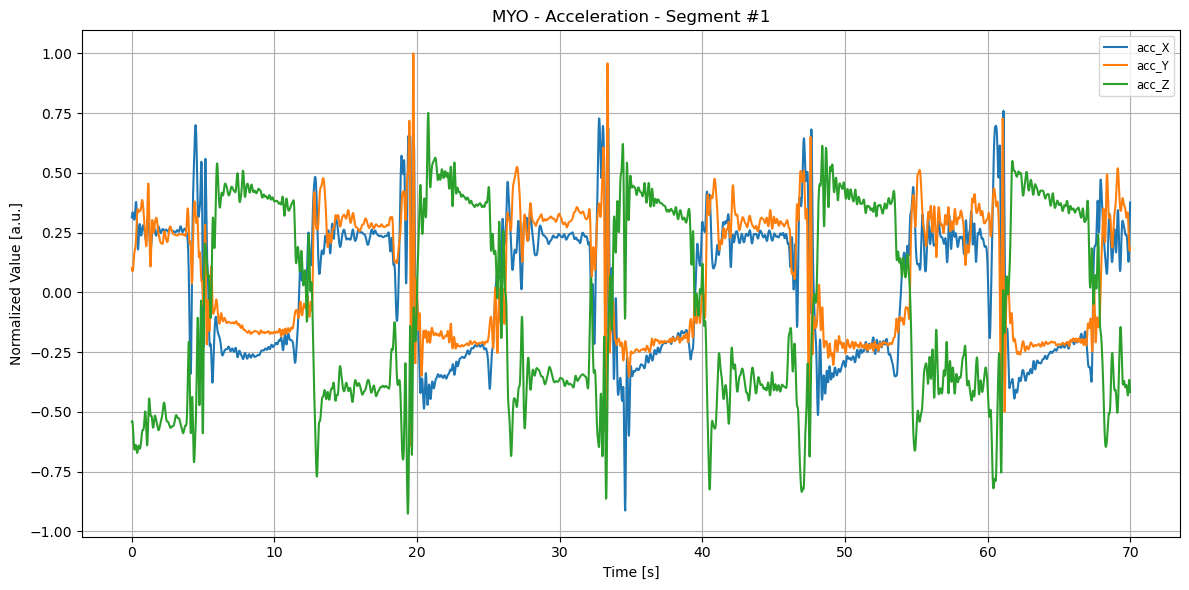

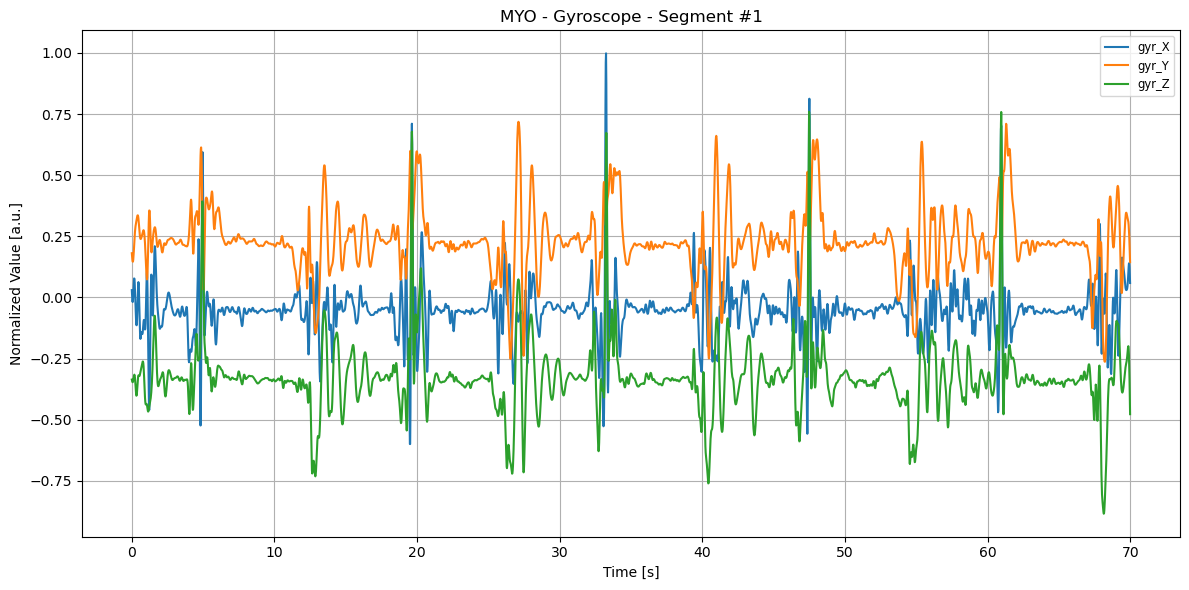

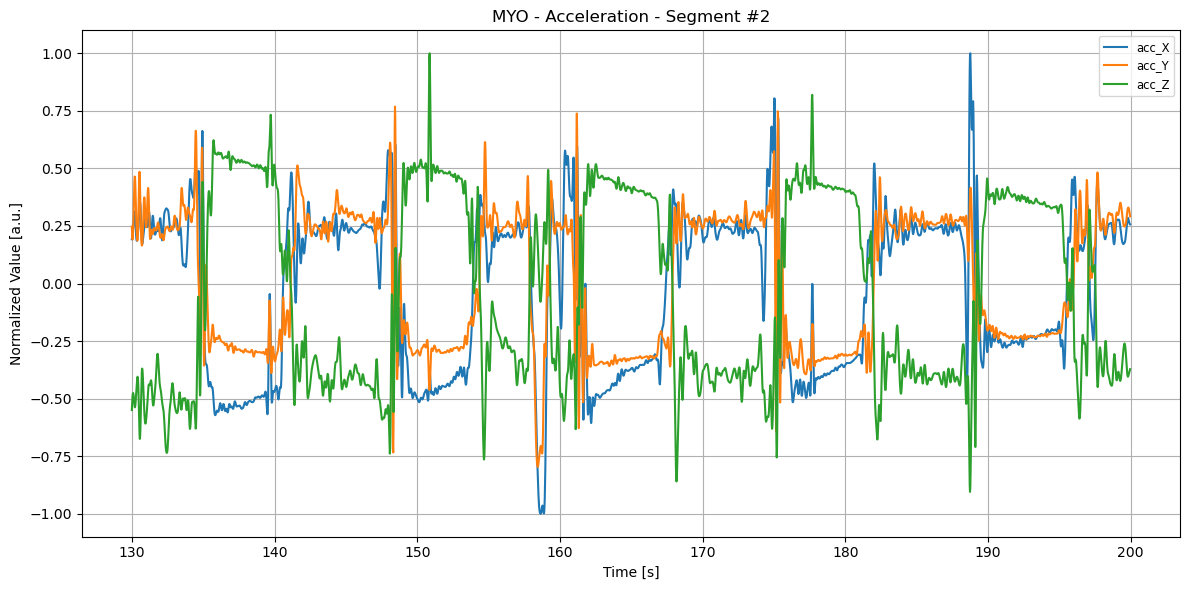

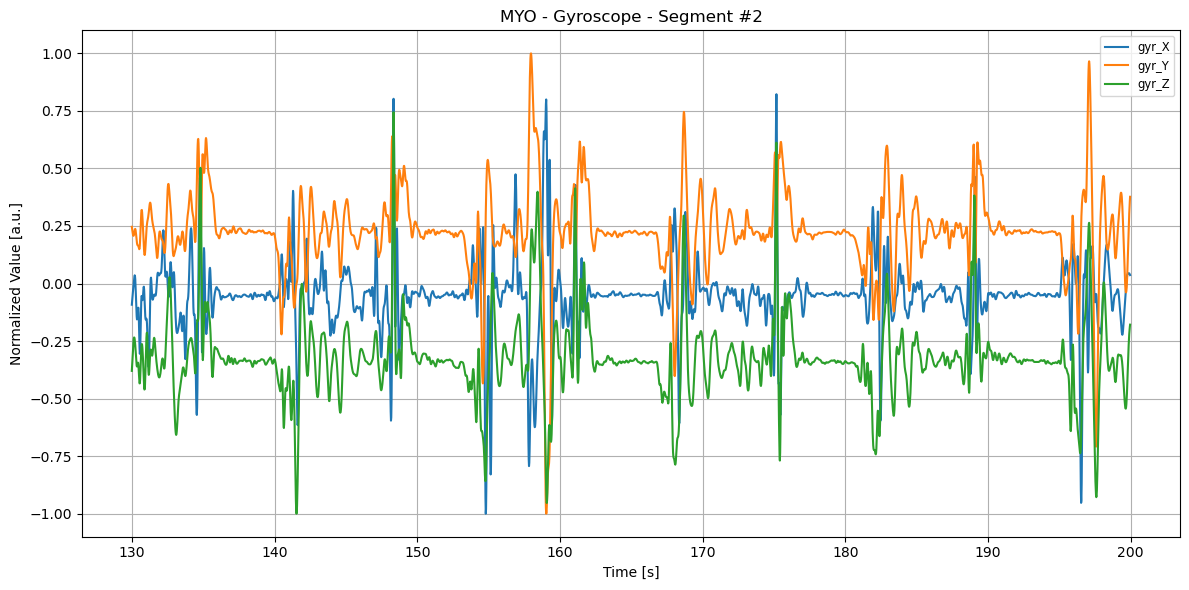

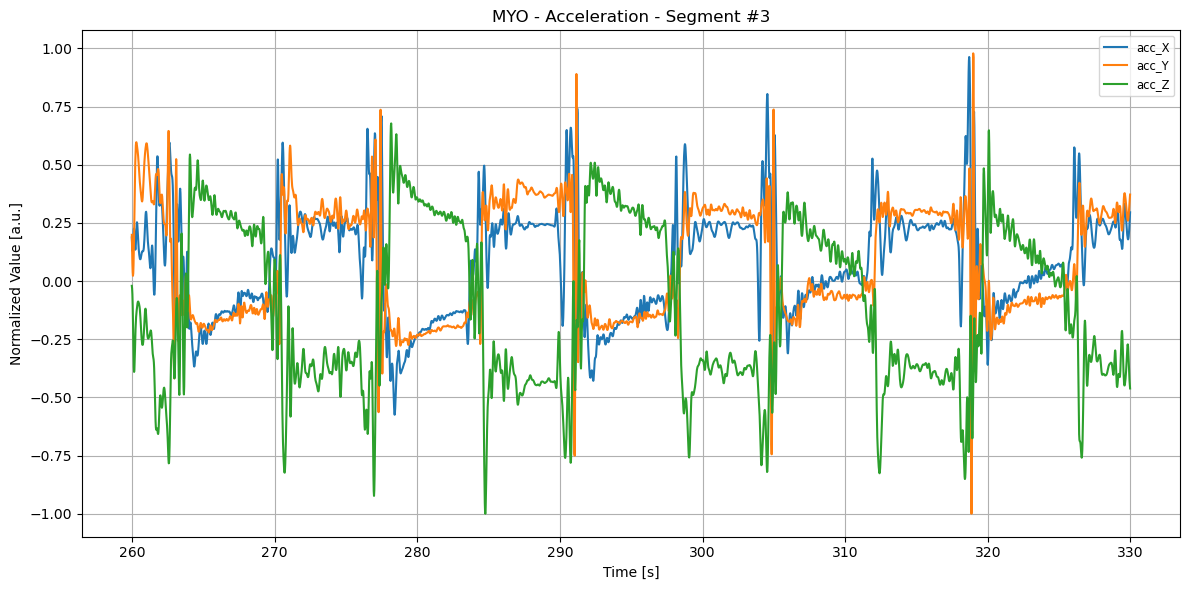

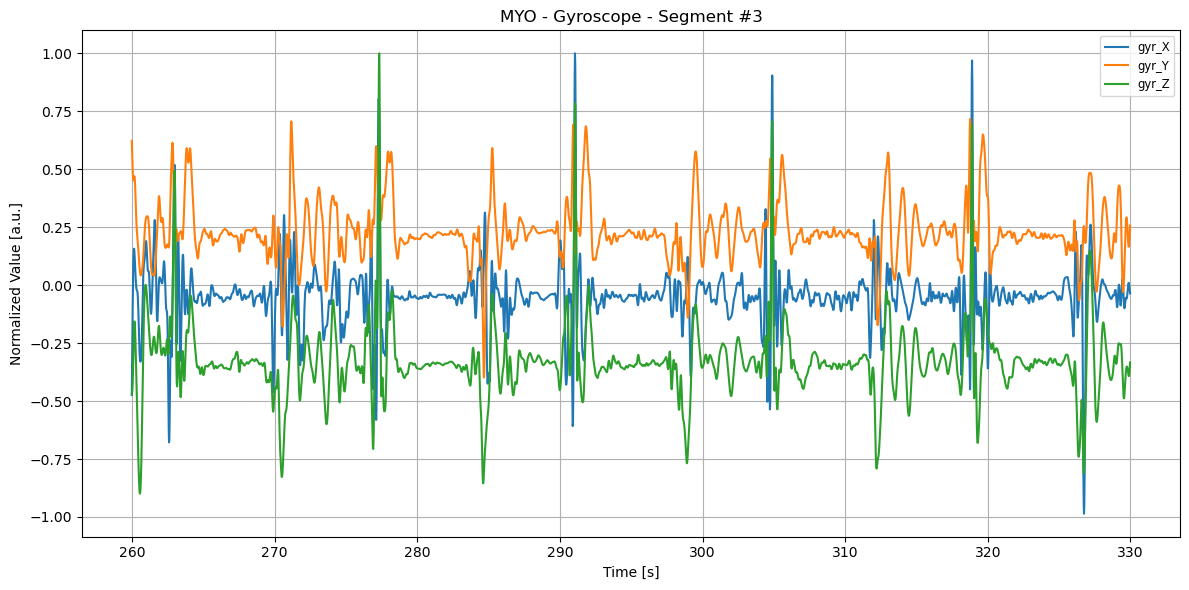

In [11]:
plot_imu_segmented_myo(imu_processed_myo, imu_myo_times_cut, flag=False)

In [12]:
segmented_imu_myo, segmented_times_myo = extract_imu_windows_myo (imu_processed_myo, imu_myo_times_cut, w_d, ov)

In [13]:
features_list_imu = ['MAV', 'WL', 'VAR', 'WAMP', 'ZC', 'SKEW', 'MNF', 'MNP']

In [14]:
features_per_trial = extract_imu_features_myo(segmented_imu_myo, features_list_imu)

In [15]:
vm_features = compute_vm_features_myo(segmented_imu_myo)

In [16]:
dfs = combine_multiple_features_lists(features_per_trial, vm_features)  # Combine all feature lists into a single dataframe

In [17]:
dfs.head()

,MAV_myo_ACC_X,MNF_myo_ACC_X,MNP_myo_ACC_X,SKEW_myo_ACC_X,VAR_myo_ACC_X,WAMP_myo_ACC_X,WL_myo_ACC_X,ZC_myo_ACC_X,MAV_myo_ACC_Y,MNF_myo_ACC_Y,...,MAV_myo_GYR_Z,MNF_myo_GYR_Z,MNP_myo_GYR_Z,SKEW_myo_GYR_Z,VAR_myo_GYR_Z,WAMP_myo_GYR_Z,WL_myo_GYR_Z,ZC_myo_GYR_Z,VM_myo_ACC,VM_myo_GYR
0,0.319603,22.917655,0.016611,-0.097638,0.000124,8,0.052542,0,0.115458,30.459386,...,0.334334,23.141576,0.018176,0.534931,0.000117,8,0.041582,0,0.679611,0.380954
1,0.327521,26.000340,0.017486,0.888357,0.000551,8,0.093692,0,0.163043,24.671133,...,0.336202,25.893596,0.018406,-1.039030,0.000388,9,0.087485,0,0.735505,0.415474
2,0.333121,20.399185,0.018189,-0.856768,0.001578,9,0.200728,0,0.236405,28.337261,...,0.368941,22.340683,0.022199,0.500820,0.000804,9,0.113336,0,0.773404,0.481244
3,0.260006,31.126405,0.011516,0.457891,0.005334,9,0.243468,0,0.313356,22.009699,...,0.360590,23.828126,0.021237,0.044114,0.001084,8,0.090507,0,0.776964,0.491157
4,0.235519,25.282398,0.009184,-0.096255,0.001703,8,0.145172,0,0.341399,24.009079,...,0.324084,24.513352,0.017079,-1.589737,0.000120,5,0.046027,0,0.773423,0.447952


In [24]:
dfs.to_csv('dfs.csv', index=False)